In [17]:
!pip install statsmodels

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [19]:
# ----------------------------------------------------------------------
# 1. Data retrieval and preparation
# ----------------------------------------------------------------------

OPSD_URL = (
    "https://data.open-power-system-data.org/time_series/"
    "2020-10-06/time_series_60min_singleindex.csv"
)
LOAD_COLUMN = "DE_load_actual_entsoe_transparency"
START_DATE = "2015-01-01"

In [20]:
def load_hourly_load(url: str = OPSD_URL, column: str = LOAD_COLUMN) -> pd.Series:
    """
    Download the OPSD 60-minute file and return the German load series in MW,
    indexed by a UTC timestamp, from START_DATE onwards.

    Returns
    -------
    pd.Series
        Hourly load in MW, name='load_mw'.
    """
    df = pd.read_csv(
        url,
        usecols=["utc_timestamp", column],
        parse_dates=["utc_timestamp"],
    )
    df = df.rename(columns={"utc_timestamp": "date", column: "load_mw"})
    df = df.set_index("date").sort_index()

    load = df["load_mw"].astype(float)
    load = load[load.notna()]          # drop missing hours
    load = load.loc[START_DATE:]       # modern period only
    load.name = "load_mw"
    return load

In [21]:
def to_daily_gw(hourly_mw: pd.Series) -> pd.Series:
    """Aggregate hourly MW to DAILY average load in GW."""
    daily = hourly_mw.resample("D").mean() / 1000.0
    daily = daily.asfreq("D").interpolate("time")
    daily.name = "load_gw"
    return daily

In [22]:
def to_weekly_gw(hourly_mw: pd.Series) -> pd.Series:
    """Aggregate hourly MW to WEEKLY average load in GW (week ending Sunday)."""
    weekly = hourly_mw.resample("W").mean() / 1000.0
    weekly = weekly.asfreq("W").interpolate("time")
    weekly.name = "load_gw"
    return weekly

In [23]:
# ----------------------------------------------------------------------
# 2. Exploratory data analysis
# ----------------------------------------------------------------------

def describe_series(daily: pd.Series, weekly: pd.Series) -> pd.DataFrame:
    """Compact summary table of both frequencies."""
    def _row(s, freq):
        return {
            "frequency": freq,
            "n_obs": len(s),
            "start": s.index.min().date(),
            "end": s.index.max().date(),
            "mean_GW": round(s.mean(), 2),
            "std_GW": round(s.std(), 2),
            "min_GW": round(s.min(), 2),
            "max_GW": round(s.max(), 2),
            "n_missing": int(s.isna().sum()),
        }
    return pd.DataFrame([_row(daily, "daily"), _row(weekly, "weekly")])

In [24]:
def plot_raw_series(daily: pd.Series, weekly: pd.Series, path=None):
    """Time plots of daily and weekly load."""
    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    ax[0].plot(daily.index, daily.values, lw=0.6, color="tab:gray")
    ax[0].set_title("Daily average German electricity load")
    ax[0].set_ylabel("Load (GW)")

    ax[1].plot(weekly.index, weekly.values, lw=1.2, color="tab:blue")
    ax[1].set_title("Weekly average German electricity load")
    ax[1].set_ylabel("Load (GW)")
    ax[1].set_xlabel("Date")

    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

In [25]:
def plot_seasonality_views(weekly: pd.Series, path=None):
    """
    Two seasonality diagnostics:
      (a) year-over-year overlay of weekly load by ISO week number,
      (b) distribution of weekly load by month (box plot).
    """
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))

    # (a) seasonal subseries / year overlay
    wk = weekly.to_frame("load_gw").copy()
    wk["week"] = wk.index.isocalendar().week.astype(int)
    wk["year"] = wk.index.year
    for yr, grp in wk.groupby("year"):
        ax[0].plot(grp["week"], grp["load_gw"], lw=1, label=str(yr))
    ax[0].set_title("Weekly load by ISO week, overlaid per year")
    ax[0].set_xlabel("ISO week of year")
    ax[0].set_ylabel("Load (GW)")
    ax[0].legend(fontsize=8, ncol=2)

    # (b) monthly distribution
    wk["month"] = wk.index.month
    wk.boxplot(column="load_gw", by="month", ax=ax[1])
    ax[1].set_title("Weekly load distribution by month")
    ax[1].set_xlabel("Month")
    ax[1].set_ylabel("Load (GW)")
    fig.suptitle("")

    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

In [26]:
# ----------------------------------------------------------------------
# 3. Decomposition (trend / seasonal / residual)
# ----------------------------------------------------------------------

def decompose_weekly(weekly: pd.Series, period: int = 52, path=None):
    """
    STL decomposition of the weekly series (robust, handles gradual
    seasonal change better than the classical additive decomposition).
    Returns the fitted STL result.
    """
    stl = STL(weekly, period=period, robust=True).fit()
    fig = stl.plot()
    fig.set_size_inches(11, 8)
    fig.suptitle(f"STL decomposition of weekly load (period={period})", y=1.01)
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return stl

In [27]:
# ----------------------------------------------------------------------
# 4. Stationarity analysis
# ----------------------------------------------------------------------

def stationarity_report(series: pd.Series, name: str) -> dict:
    """
    Run ADF and KPSS on a single series and return their verdicts.

    Interpretation:
      ADF  H0 = 'has a unit root' (non-stationary).  Reject (p<0.05) => stationary.
      KPSS H0 = 'is (trend) stationary'.             Reject (p<0.05) => non-stationary.

    The two tests are complementary; agreement gives a confident verdict.
    """
    s = series.dropna()

    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    # KPSS around a constant level; 'ct' would test trend-stationarity
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")

    adf_stationary = adf_p < 0.05
    kpss_stationary = kpss_p > 0.05  # fail to reject stationarity

    if adf_stationary and kpss_stationary:
        verdict = "stationary"
    elif not adf_stationary and not kpss_stationary:
        verdict = "non-stationary"
    else:
        verdict = "ambiguous / difference-or-trend-stationary"

    return {
        "series": name,
        "ADF_stat": round(adf_stat, 3),
        "ADF_p": round(adf_p, 4),
        "ADF_says": "stationary" if adf_stationary else "non-stationary",
        "KPSS_stat": round(kpss_stat, 3),
        "KPSS_p": round(kpss_p, 4),
        "KPSS_says": "stationary" if kpss_stationary else "non-stationary",
        "verdict": verdict,
    }

In [28]:
def stationarity_table(weekly: pd.Series) -> pd.DataFrame:
    """
    Test the level series and common transforms used to remove
    trend and annual seasonality (period = 52 weeks).
    """
    d1 = weekly.diff().dropna()                 # first difference (removes trend)
    d52 = weekly.diff(52).dropna()              # seasonal difference (removes annual season)
    d1_52 = weekly.diff().diff(52).dropna()     # both

    rows = [
        stationarity_report(weekly, "level"),
        stationarity_report(d1, "first diff (d=1)"),
        stationarity_report(d52, "seasonal diff (D=1, s=52)"),
        stationarity_report(d1_52, "first + seasonal diff"),
    ]
    return pd.DataFrame(rows)

In [29]:
def plot_acf_pacf(series: pd.Series, lags: int = 60, title: str = "", path=None):
    """ACF and PACF side by side -- reads off AR/MA and seasonal structure."""
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    plot_acf(series.dropna(), lags=lags, ax=ax[0])
    plot_pacf(series.dropna(), lags=lags, ax=ax[1], method="ywm")
    ax[0].set_title(f"ACF {title}")
    ax[1].set_title(f"PACF {title}")
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

In [30]:
def plot_rolling_stats(weekly: pd.Series, window: int = 52, path=None):
    """Rolling mean and std -- a visual, informal stationarity check."""
    roll_mean = weekly.rolling(window).mean()
    roll_std = weekly.rolling(window).std()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(weekly.index, weekly, lw=1, color="tab:gray", label="weekly load")
    ax.plot(roll_mean.index, roll_mean, color="tab:red", label=f"rolling mean ({window}w)")
    ax.plot(roll_std.index, roll_std, color="tab:green", label=f"rolling std ({window}w)")
    ax.set_title("Rolling mean and standard deviation")
    ax.set_ylabel("Load (GW)")
    ax.legend()
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

Summary
   frequency  n_obs       start         end  mean_GW  std_GW  min_GW  max_GW  \
0     daily   2100  2015-01-01  2020-09-30    55.49    6.60   38.95   68.18   
1    weekly    301  2015-01-04  2020-10-04    55.48    3.76   46.51   63.59   

   n_missing  
0          0  
1          0   

Stationarity
                       series  ADF_stat   ADF_p    ADF_says  KPSS_stat  KPSS_p  \
0                      level    -4.047  0.0012  stationary      0.160    0.10   
1           first diff (d=1)    -7.069  0.0000  stationary      0.056    0.10   
2  seasonal diff (D=1, s=52)    -4.295  0.0005  stationary      1.342    0.01   
3      first + seasonal diff    -7.278  0.0000  stationary      0.105    0.10   

        KPSS_says                                     verdict  
0      stationary                                  stationary  
1      stationary                                  stationary  
2  non-stationary  ambiguous / difference-or-trend-stationary  
3      stationary             

C:\Users\DELL\AppData\Local\Temp\ipykernel_15480\3549157922.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
C:\Users\DELL\AppData\Local\Temp\ipykernel_15480\3549157922.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
C:\Users\DELL\AppData\Local\Temp\ipykernel_15480\3549157922.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
C:\Users\DELL\AppData\Local\Temp\ipykernel_15480\3549157922.py:19: InterpolationWarning: The test statisti

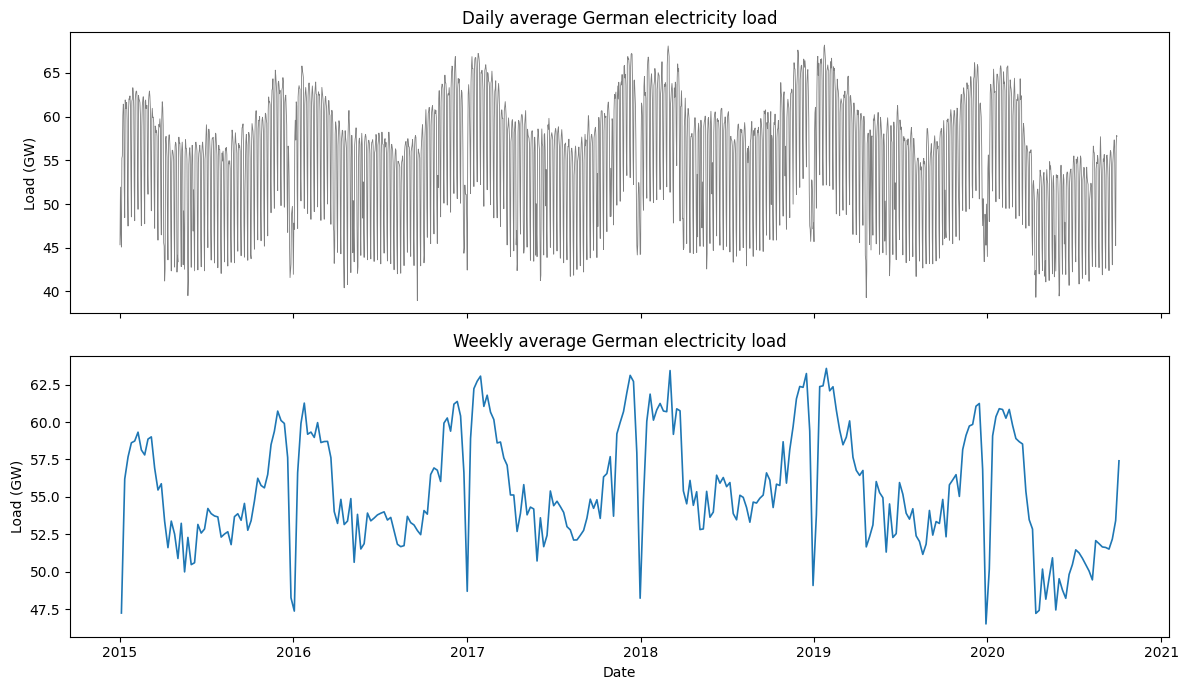

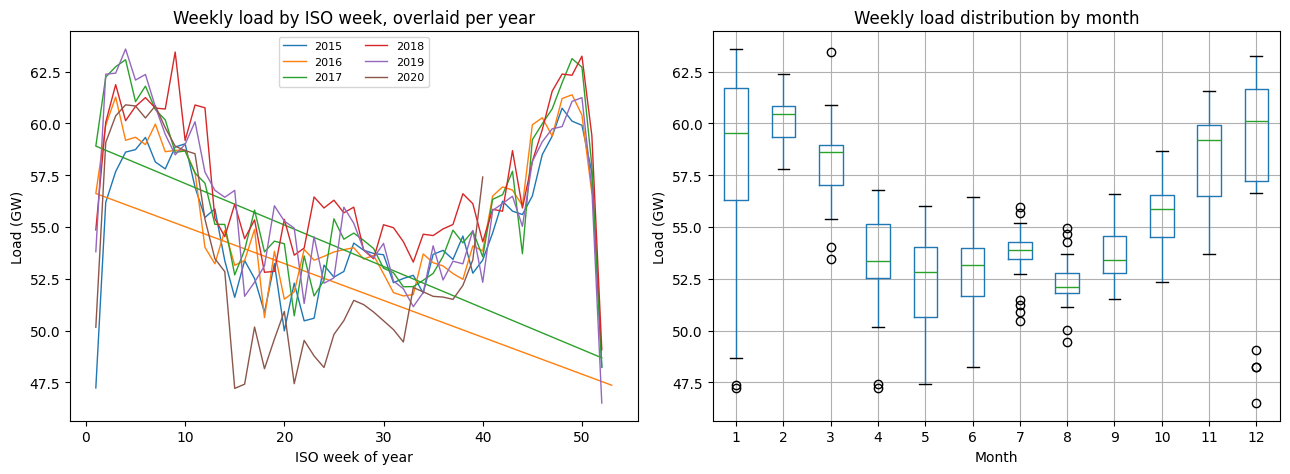

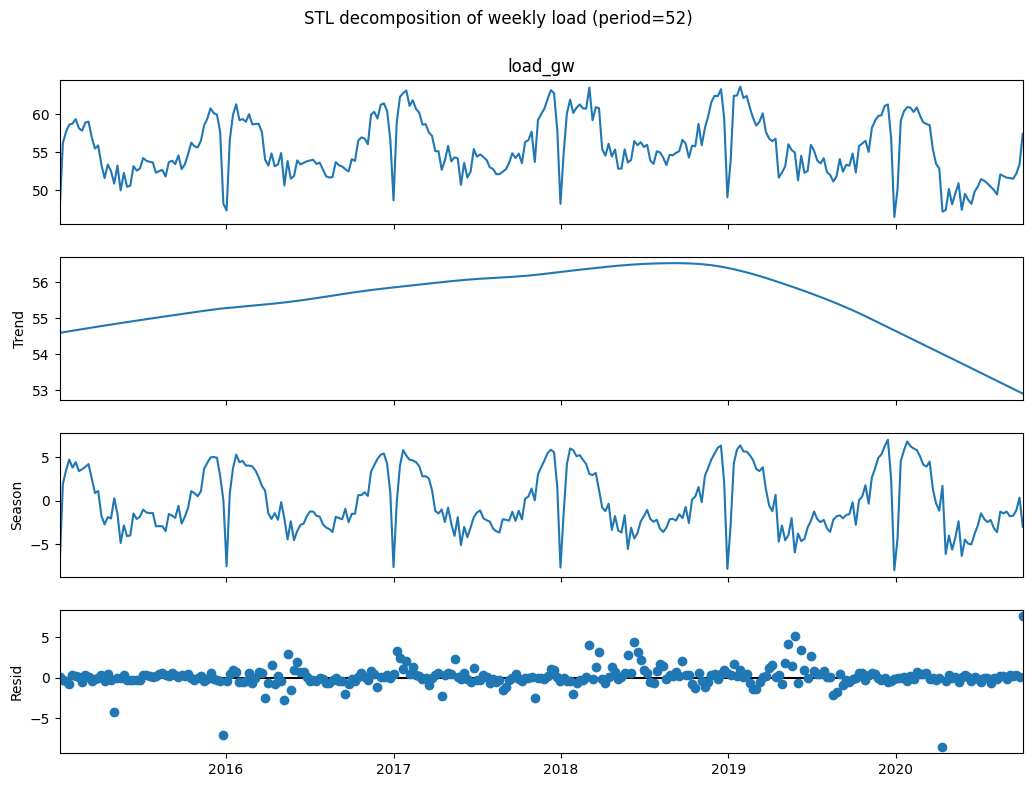

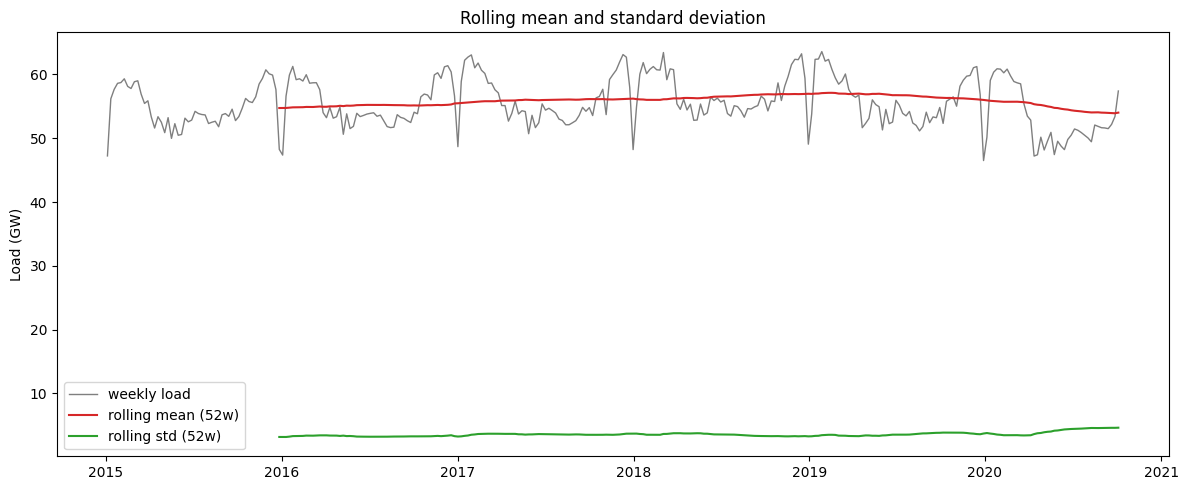

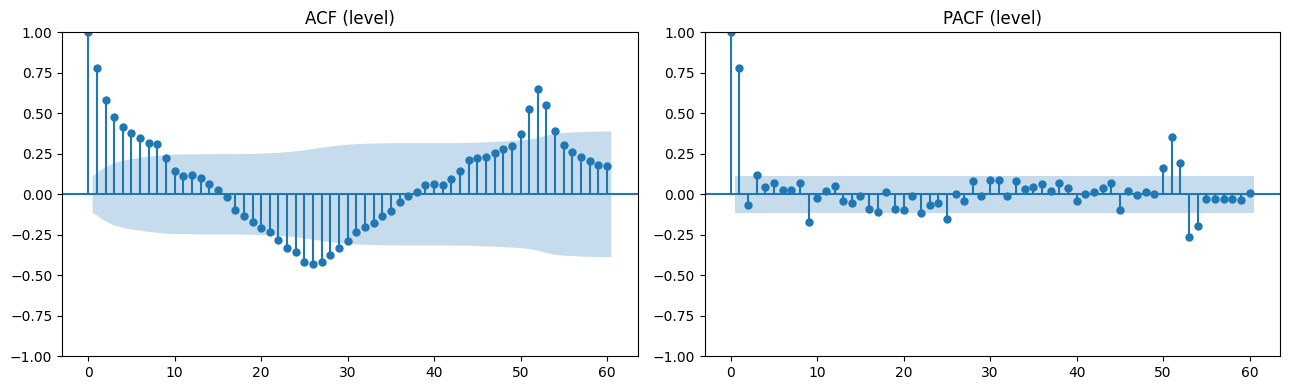

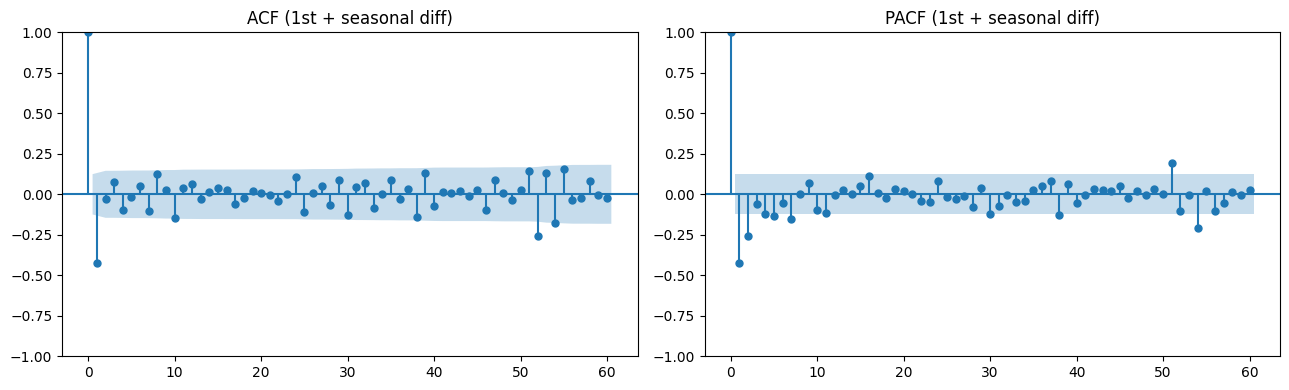

In [33]:
def run_part1(save_dir: str | None = None):
    """Execute the full Part 1 workflow on the real OPSD data."""
    import os

    hourly = load_hourly_load()
    daily = to_daily_gw(hourly)
    weekly = to_weekly_gw(hourly)

    os.makedirs("data/processed", exist_ok=True)
    weekly.to_csv("data/processed/weekly_load.csv")
    daily.to_csv("data/processed/daily_load.csv")

    print("Summary\n", describe_series(daily, weekly), "\n")
    print("Stationarity\n", stationarity_table(weekly), "\n")

    def p(fname):
        return os.path.join(save_dir, fname) if save_dir else None

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    plot_raw_series(daily, weekly, p("01_raw_series.png"))
    plot_seasonality_views(weekly, p("02_seasonality.png"))
    decompose_weekly(weekly, path=p("03_stl_decomposition.png"))
    plot_rolling_stats(weekly, path=p("04_rolling_stats.png"))
    plot_acf_pacf(weekly, title="(level)", path=p("05_acf_pacf_level.png"))
    plot_acf_pacf(weekly.diff().diff(52), title="(1st + seasonal diff)",
                  path=p("06_acf_pacf_diff.png"))

    return daily, weekly


if __name__ == "__main__":
    run_part1(save_dir="outputs/01/figures")